In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from ydata_profiling import ProfileReport
%matplotlib inline


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    accuracy_score,
    classification_report,
    confusion_matrix
)

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA


# DSC 530 Final Project:
# *Do Airbnb reviews or subsequent data help to predict the price?*

# 1. Dataset selection & preliminary preparation


In [2]:
df = pd.read_csv("/Users/doug/PycharmProjects/listings.csv")

print(f"Dataset Shape: {df.shape}")

print("\n--- First 10 Rows ---")
print(df.head(10))

print("\n--- Last 10 Rows ---")
print(df.tail(10))

Dataset Shape: (13162, 79)

--- First 10 Rows ---
       id                          listing_url       scrape_id last_scraped  \
0       6       https://www.airbnb.com/rooms/6  20250925032747   2025-09-25   
1   12447   https://www.airbnb.com/rooms/12447  20250925032747   2025-09-25   
2   29967   https://www.airbnb.com/rooms/29967  20250925032747   2025-09-25   
3   62274   https://www.airbnb.com/rooms/62274  20250925032747   2025-09-25   
4   62949   https://www.airbnb.com/rooms/62949  20250925032747   2025-09-25   
5   75668   https://www.airbnb.com/rooms/75668  20250925032747   2025-09-25   
6   77785   https://www.airbnb.com/rooms/77785  20250925032747   2025-09-25   
7   79300   https://www.airbnb.com/rooms/79300  20250925032747   2025-09-25   
8  103417  https://www.airbnb.com/rooms/103417  20250925032747   2025-09-25   
9  103720  https://www.airbnb.com/rooms/103720  20250925032747   2025-09-25   

            source                                               name  \
0      

# 2. Data Cleaning and Preparation

In [3]:
print("\n--- DataFrame Info ---")

df.info(verbose=True, show_counts=True)


--- DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13162 entries, 0 to 13161
Data columns (total 79 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            13162 non-null  int64  
 1   listing_url                                   13162 non-null  object 
 2   scrape_id                                     13162 non-null  int64  
 3   last_scraped                                  13162 non-null  object 
 4   source                                        13162 non-null  object 
 5   name                                          13162 non-null  object 
 6   description                                   13001 non-null  object 
 7   neighborhood_overview                         7768 non-null   object 
 8   picture_url                                   13162 non-null  object 
 9   host_id                              

In [4]:
# are there dupes?
print(f"\n --- Duplicate Rows ---")
print(f"Number of completely duplicate rows: {df.duplicated().sum()}")


 --- Duplicate Rows ---
Number of completely duplicate rows: 0


# Quick observations

1. Dataset shape is large. 13,162 rows and 79 columns. Seems we have a rich set of features to explore
2. target variable -> immediate thought is the rating of the listing, **review_scores_rating** . there is a chunk of missing values that i'll need to address

## Key issues
1. a decent amount of missing values. Are these columns crucial to the analysis though?
2. data type mismatches . the best (actually worst) part of python. Price is listed as an object, probably because of the $ . will need to convert to float. date columns are listed as object. will have to convert to datetime. Numeric columns are showing as object instead (host_acceptance rate, host_response_rate)


# quick thoughts
1. scrape id is constant. this makes sense. last date scraped is also constant, that is good to see. Both indicate scrape was done by the same person at the same date
2. missing values of price and beds. roughly the same number of missing values. will probably drop any rows that do not have both values
3. will drop the calculated_host_XXXX columns . they are mostly 0's
4. Will convert host_since and a few other date fields into float, making it a days since today field. will try to use as a predictor of price
5. Some text fields are actually boolen -> instant bookable
----------------------------------------------------------------------------------------------------------

# Reviewing Price
## this is showing as a text field, it also looks like it's a price per day given how low the values are. 
## *action plan to get Price into a usable format* 
1. remove non-numeric characters and convert value to float
2. handle extreme outliers, possibly capping, log transforming or filtering them out during modeling


# Normalizing the data
- Had to remove the top 2% of price listings. After doing all the analysis none of the results were useful due to the extreme high priced outliers. 

In [5]:
df_clean = df.copy() 

# clean up price
df['price'] = (df['price']
               .astype(str)
               .str.replace(r'[\$,]', '', regex=True)
               .replace('nan', np.nan)
               .astype(float))

df_clean['price'] = (df['price']
               .astype(str)
               .str.replace(r'[\$,]', '', regex=True)
               .replace('nan', np.nan)
               .astype(float))

In [6]:
# circling back at this point. Have done the rest of the analysis but need to redo the analysis below with the data cleansed better. 
# Instead of just plotting the price with cap at 98%, need to drop those rows from the data here 

# Store original row count before filtering
if 'original_rows' not in globals():
    original_rows = len(df_clean)

# Calculate quantile
price_threshold = df_clean['price'].quantile(0.98)

print(f"Price threshold (98th percentile): ${price_threshold:,.2f}")

# Filter the dataframe
df_clean = df_clean[df_clean['price'] <= price_threshold].copy().reset_index(drop=True)

print(f"Original rows: {original_rows}")
print(f"Rows after removing top 2%: {len(df_clean)}")
print(f"Rows removed: {original_rows - len(df_clean)} ({(original_rows - len(df_clean))/original_rows:.2%})")


Price threshold (98th percentile): $1,400.40
Original rows: 13162
Rows after removing top 2%: 11153
Rows removed: 2009 (15.26%)


In [7]:
# clean percentage columns
df_clean['host_response_rate'] = df_clean['host_response_rate'].str.replace('%','').astype(float) / 100.0

df_clean['host_acceptance_rate'] = df_clean['host_acceptance_rate'].str.replace('%','').astype(float) / 100.0

In [8]:
# look at the changes
print("Data types after cleaning price and percentages")
print(df_clean[['price', 'host_response_rate', 'host_acceptance_rate']].dtypes)

Data types after cleaning price and percentages
price                   float64
host_response_rate      float64
host_acceptance_rate    float64
dtype: object


In [9]:
# convert date columns to date time objects 
date_cols = ['last_scraped', 'host_since', 'first_review', 'last_review']

for col in date_cols:
    df_clean[col] = pd.to_datetime(df_clean[col], errors='coerce')

In [10]:
# feature engineering - add host tenure days 
df_clean['host_tenure_days'] = (df_clean['last_scraped'] - df_clean['host_since']).dt.days

# check to see if this column is a numeric value now
display(df_clean['host_tenure_days'].head())

0    6415.0
1    5812.0
2    5606.0
3    5415.0
4    5947.0
Name: host_tenure_days, dtype: float64

In [11]:
# date_cols = ['last_scraped', 'host_since', 'first_review', 'last_review']

# for col in date_cols:
    # df_clean[col] = pd.to_datetime(df[col], errors='coerce')
    # feature engineering - add host tenure days -- doing it for original df for correlation matrix purposes

df['last_scraped'] = pd.to_datetime(df['last_scraped'], errors='coerce')
df['host_since'] = pd.to_datetime(df['host_since'], errors='coerce')
# Calculate tenure
df['host_tenure_days'] = (df['last_scraped'] - df['host_since']).dt.days

In [12]:
# need to use host_is_superhost - creating assumption, if column is null fill with false

df_clean['host_is_superhost'] = df['host_is_superhost'].fillna(False)


# update to better boolean field.  if t fill as 1 and if f or false (from me above being silly) fill as 0 
# Replace 't' with 1 and 'f' with 0
df_clean['host_is_superhost'] = df_clean['host_is_superhost'].replace({'t': 1, 'f': 0, 'False': 0})

print(df_clean['host_is_superhost'].value_counts(dropna=False))


host_is_superhost
1    5855
0    5298
Name: count, dtype: int64


In [13]:
# update instant bookable to true boolean column
df_clean['instant_bookable'] = df_clean['instant_bookable'].replace({'t': 1, 'f': 0})

print(df_clean['instant_bookable'].value_counts(dropna=False))

instant_bookable
0    6955
1    4198
Name: count, dtype: int64


/var/folders/l0/w4cn9b_s39l3p2c89ztml7zw0000gn/T/ipykernel_24163/1996693092.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_clean['instant_bookable'] = df_clean['instant_bookable'].replace({'t': 1, 'f': 0})


In [14]:
# drop unnecessary columns
# calendar updated was completely null
# urls are not useful
# scrape id is constant and not useful
cols_to_drop = ['calendar_updated', 'listing_url', 'scrape_id', 'picture_url', 'host_url',
                'host_thumbnail_url', 'host_picture_url']

df_clean = df_clean.drop(columns=cols_to_drop)
print(f"Dropped {len(cols_to_drop)} columns.")
print(f"New Dataset shape: {df_clean.shape}")

Dropped 7 columns.
New Dataset shape: (11153, 73)


In [15]:
# summary stats 
print(df_clean.describe())

                 id         last_scraped       host_id  \
count  1.115300e+04                11153  1.115300e+04   
mean   6.823701e+17  2025-09-25 00:00:00  1.925289e+08   
min    6.000000e+00  2025-09-25 00:00:00  2.900000e+01   
25%    4.243734e+07  2025-09-25 00:00:00  2.903553e+07   
50%    8.058196e+17  2025-09-25 00:00:00  1.033499e+08   
75%    1.213776e+18  2025-09-25 00:00:00  3.556271e+08   
max    1.516933e+18  2025-09-25 00:00:00  7.197071e+08   
std    5.744238e+17                  NaN  2.002959e+08   

                          host_since  host_response_rate  \
count                          11132        10203.000000   
mean   2017-09-20 22:50:08.839382016            0.971115   
min              2008-03-03 00:00:00            0.000000   
25%              2015-03-13 00:00:00            1.000000   
50%              2016-11-08 00:00:00            1.000000   
75%              2020-07-15 00:00:00            1.000000   
max              2025-09-18 00:00:00            1.000000 

# 2. Univariate Analysis
## Descriptive Statistics

In [16]:
# Descriptive statistics for numerical variables
numeric_cols = df_clean.select_dtypes(include=np.number).columns

univariate_stats = pd.DataFrame({
    'Mean': df_clean[numeric_cols].mean(),
    'Median': df_clean[numeric_cols].median(),
    'Variance': df_clean[numeric_cols].var(),
    'Skewness': df_clean[numeric_cols].skew(),
    'Kurtosis': df_clean[numeric_cols].kurtosis()
})

univariate_stats

,Mean,Median,Variance,Skewness,Kurtosis
id,6.823701e+17,8.058196e+17,3.299627e+35,-0.092505,-1.605238
host_id,1.925289e+08,1.033499e+08,4.011844e+16,0.906966,-0.465231
host_response_rate,9.711154e-01,1.000000e+00,1.506351e-02,-6.074096,40.225452
host_acceptance_rate,9.049190e-01,9.900000e-01,4.151143e-02,-2.954352,8.710763
host_listings_count,5.638771e+01,4.000000e+00,1.003539e+05,10.570673,119.693137
host_total_listings_count,8.707743e+01,6.000000e+00,1.982598e+05,9.156687,95.417908
neighbourhood_group_cleansed,NaN,NaN,NaN,NaN,NaN
latitude,3.276950e+01,3.275995e+01,4.165567e-03,0.780424,2.523782
longitude,-1.171834e+02,-1.171725e+02,4.307199e-03,0.539525,-0.253936
accommodates,5.053259e+00,4.000000e+00,1.082858e+01,1.272176,1.542753



### Now with clean data I can begin the deep dive. Univariate analysis involves examining single variables to understand their characteristics. I will focus on: 
1. The target variable (review_scores_rating): understanding the distribution is crucial to frame the model problem
2. The key predictor (price): analyzing the distribution, identifying outliers, and understanding the typical price points
3. The engineered feature (host_tenure_days): investigating the experience level of hosts on the platform
4. Key categorical variables: examining the distribution of features like room_type and property_type

### Visuals

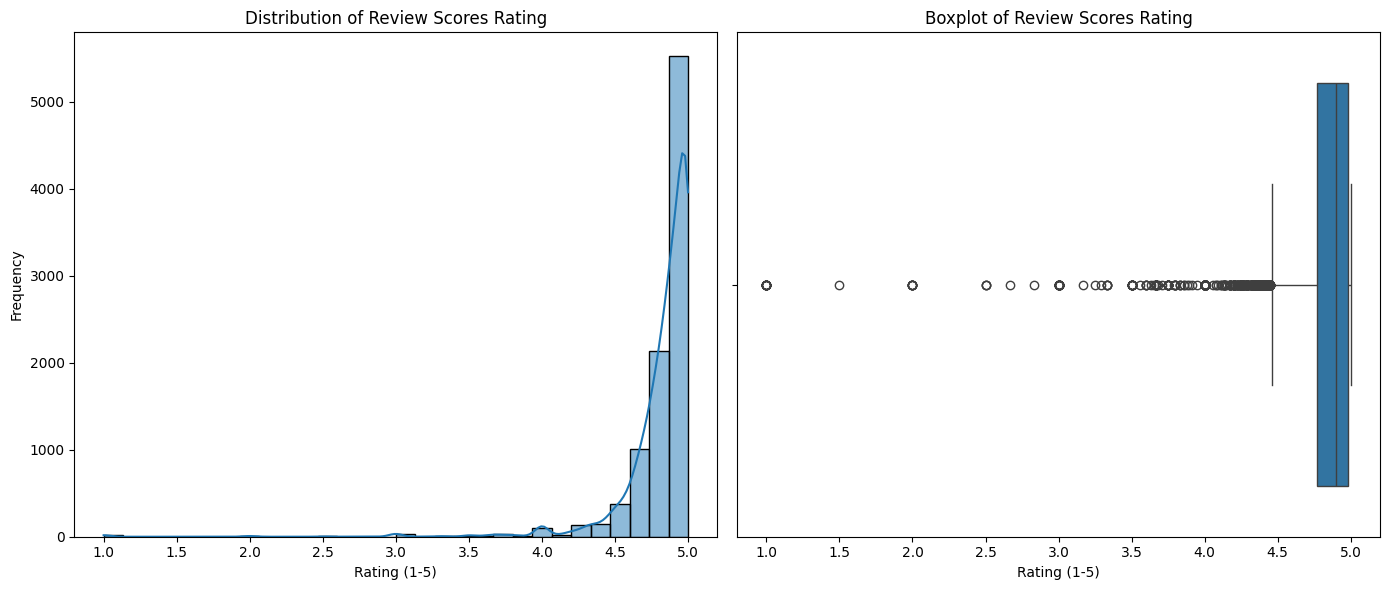

Summary statistics for Review Scores Rating:


count    9565.000000
mean        4.822018
std         0.291682
min         1.000000
25%         4.770000
50%         4.900000
75%         4.980000
max         5.000000
Name: review_scores_rating, dtype: float64

In [17]:
# analyzing the target variable - review_scores_rating
plt.figure(figsize=(14,6))

# plot the histogram
plt.subplot(1, 2, 1)
sns.histplot(df_clean['review_scores_rating'],
             kde=True, bins=30)
plt.title('Distribution of Review Scores Rating')
plt.xlabel('Rating (1-5)')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.boxplot(x=df_clean['review_scores_rating'])
plt.title('Boxplot of Review Scores Rating')
plt.xlabel('Rating (1-5)')

plt.tight_layout()
plt.show()

# print summary stats
print("Summary statistics for Review Scores Rating:")
display(df_clean['review_scores_rating'].describe())

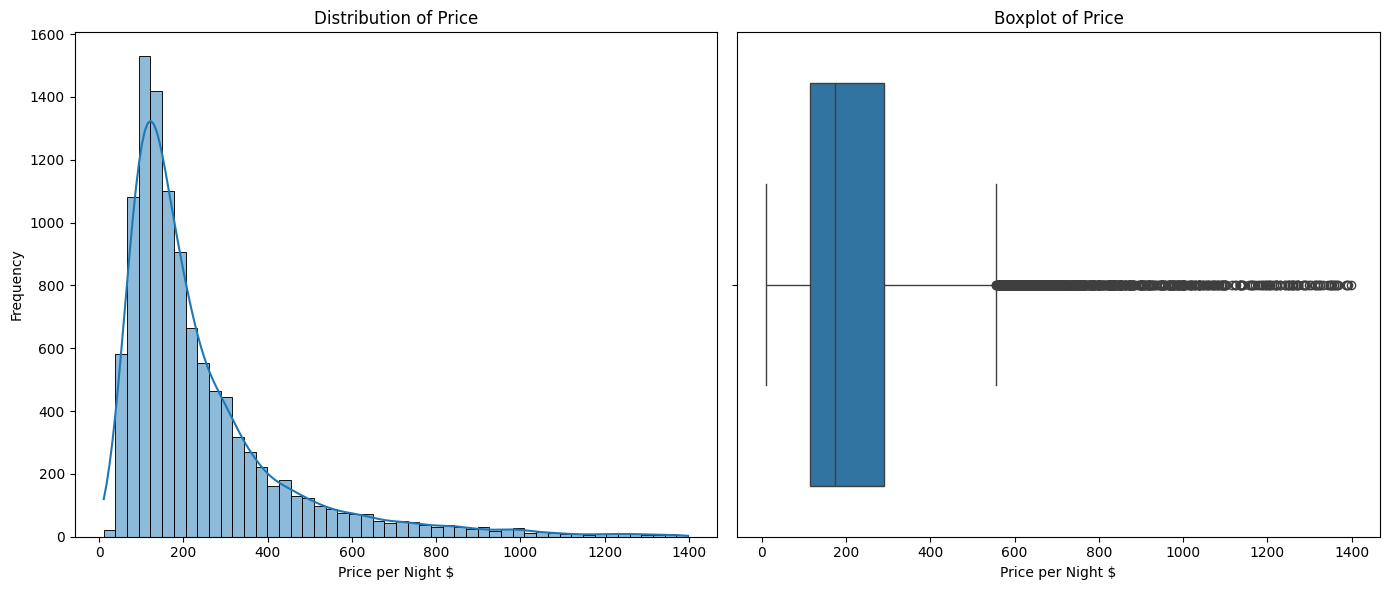

Summary statistics for Price:


count    11153.000000
mean       239.324397
std        199.321095
min         11.000000
25%        114.000000
50%        174.000000
75%        291.000000
max       1398.000000
Name: price, dtype: float64

In [18]:
# analyzing price


plt.figure(figsize=(14,6))

# plot the histogram
plt.subplot(1, 2, 1)
sns.histplot(df_clean['price'],
             kde=True, bins=50)
plt.title(f'Distribution of Price')
plt.xlabel('Price per Night $')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.boxplot(x=df_clean['price'])
plt.title(f'Boxplot of Price')
plt.xlabel('Price per Night $')


plt.tight_layout()
plt.show()

# print summary stats
print("Summary statistics for Price:")
display(df_clean['price'].describe())

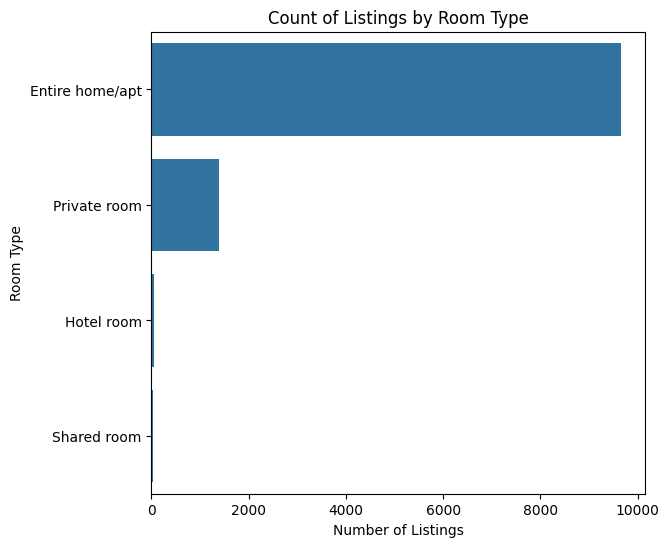

Value counts for Room Type:
room_type
Entire home/apt    86.631400
Private room       12.498879
Hotel room          0.520039
Shared room         0.349682
Name: proportion, dtype: float64


In [19]:
# analyzing key categorical variable - room type
plt.figure(figsize=(14,6))

# plot the histogram
plt.subplot(1, 2, 1)
sns.countplot(data = df_clean , y ='room_type', order = df_clean['room_type'].value_counts().index)
plt.title(f'Count of Listings by Room Type')
plt.xlabel('Number of Listings')
plt.ylabel('Room Type')

plt.show()

# print summary stats
print("Value counts for Room Type:")
print(df_clean['room_type'].value_counts(normalize=True)*100)

# Observations:

## Review Scores Rating:
- NOT a uniform distribution.
- Most reviews are 5. the bottom 25% quartile is a score of 4.76.
- This tells me that either people don't take time to post average scoring reviews or somehow the host / system is filtering those ones out. 

## Price:
- price ranging from $11 -$5,000 per night.
- It really is going to depend on if you are on the nice and beach part of San Diego or in the , uhm, less nice area and surronded by less than ideal homes and places.
- Modifying price to cap at $1,400 removes about 220 listings, but helps the distribution avoid a right tail skew. 

## Room Type:
- Well, was hoping for a bit more equal distribution here. But from personal experience I typically want the entire home or apartment when renting an AirBNB.
- Since 84% of listings are entire home / apt, I am going to hypothesize that this type of room will have different pricing and possibly different ratings compared to private rooms. I will explore this relationship in the next step. 

# 3. Bivariate analysis
##  Scatterplots / box plots & Correlation heatmap
## Goal
### uncover factors that might influence a listing's rating. I will investigate:
1. Numerical vs. Target: Is there a relationship between price or host tenure and the review score?
2. Categorical vs. Target: Do different room types or property types receive systematically different ratings?
3. Numerical vs. Numerical: How do our key numeric features relate to each other? Will build a correlation matrix to get a broad overview. 

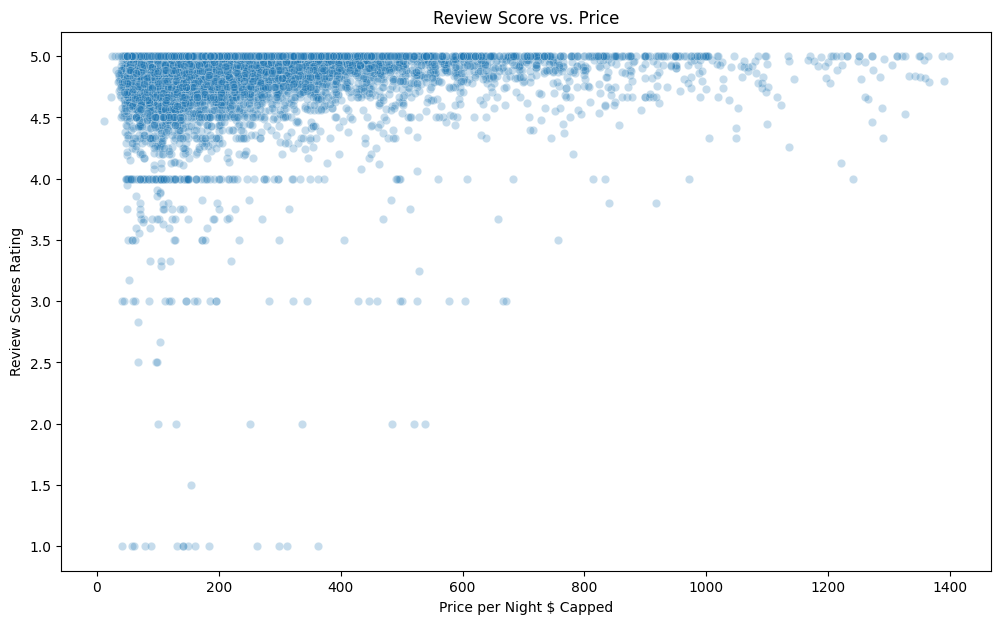

In [20]:
# price v review score

# use same capped dataframe for a clearer plot
plt.figure(figsize=(12, 7))

sns.scatterplot(data = df_clean, x='price', y='review_scores_rating', alpha = 0.25)
# alpha makes points transparent to show density

plt.title('Review Score vs. Price')
plt.xlabel('Price per Night $ Capped')
plt.ylabel('Review Scores Rating')
plt.show()

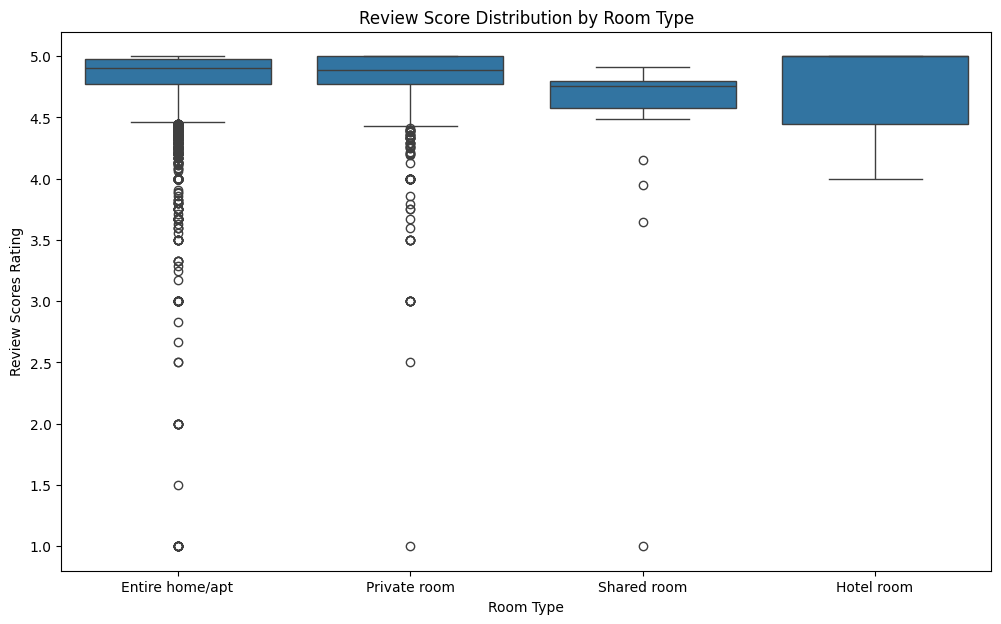

In [21]:
# room type v review score
plt.figure(figsize=(12,7))

sns.boxplot(data=df_clean , x='room_type', y='review_scores_rating', 
            order=['Entire home/apt', 'Private room', 'Shared room', 'Hotel room'])

plt.title('Review Score Distribution by Room Type')
plt.xlabel('Room Type')
plt.ylabel('Review Scores Rating')
plt.show()

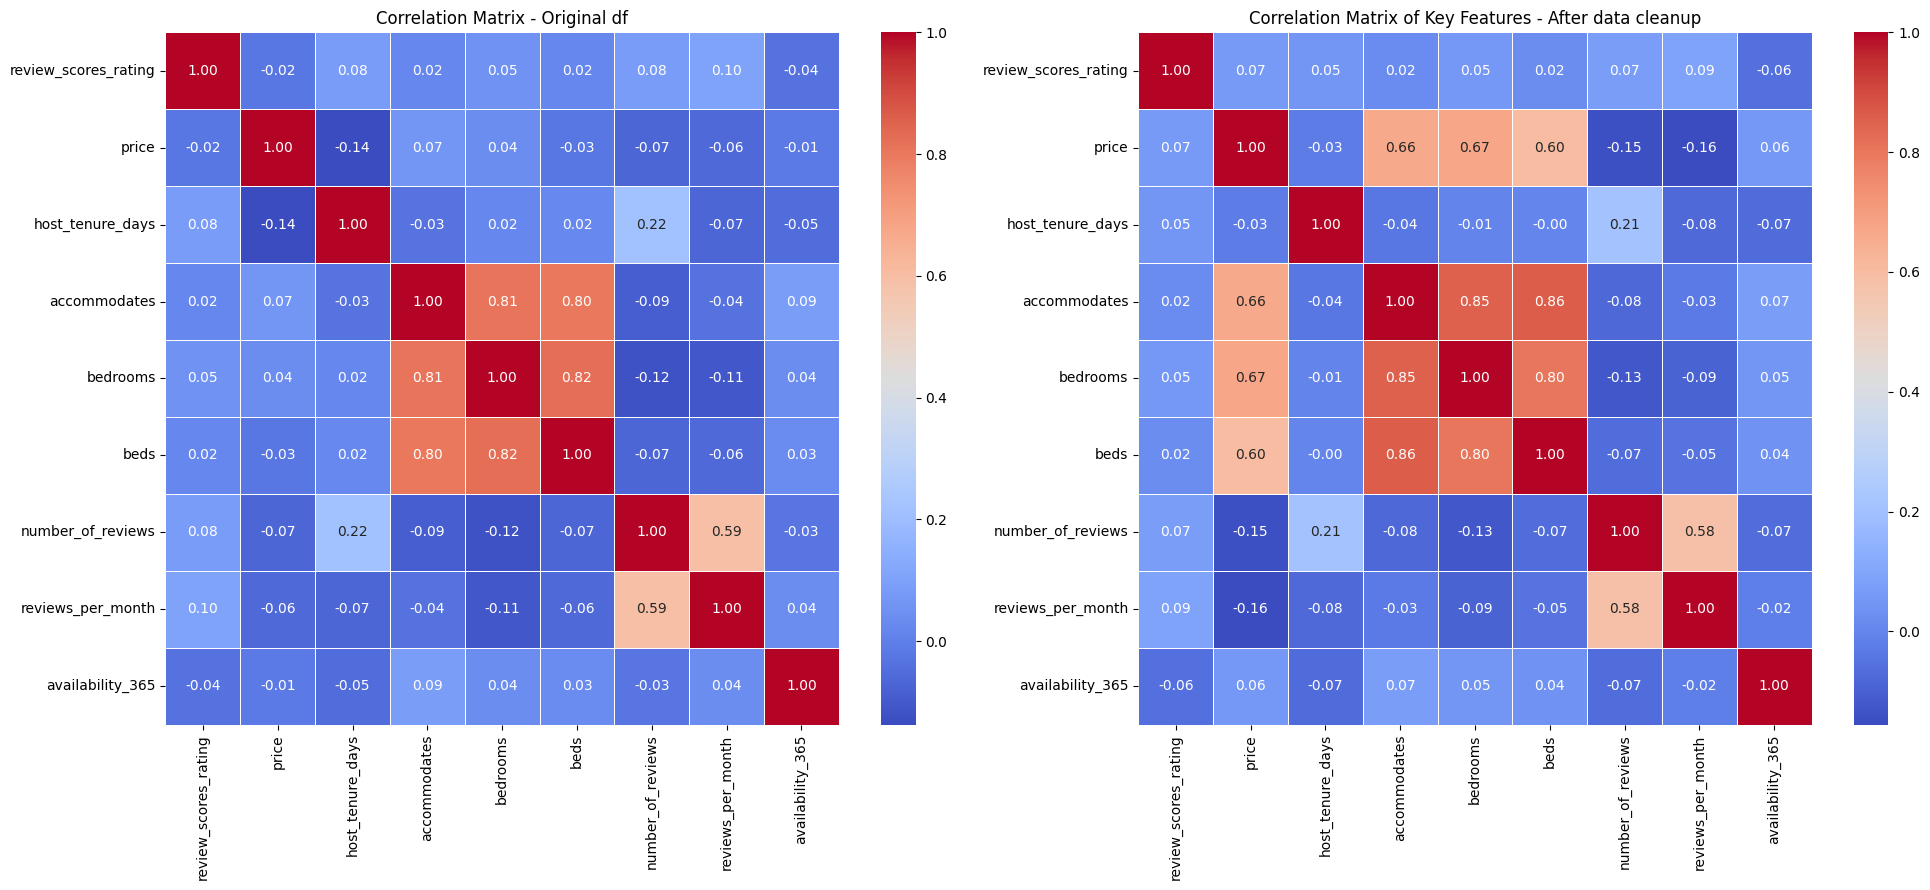

In [22]:

# correlation matrix of key numerical features

numeric_cols_for_corr = [
    'review_scores_rating', 'price', 'host_tenure_days', 'accommodates', 'bedrooms', 
    'beds', 'number_of_reviews',  'reviews_per_month', 'availability_365']

corr_matrix = df_clean[numeric_cols_for_corr].corr()
corr_df = df[numeric_cols_for_corr].corr()

fig, axes = plt.subplots(1, 2, figsize=(20, 9))

sns.heatmap(corr_df, annot=True, cmap='coolwarm',  fmt='.2f', linewidths=0.5, ax=axes[0])
axes[0].set_title('Correlation Matrix - Original df')


# plt.figure(figsize=(12,9))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidth=.5)
axes[1].set_title('Correlation Matrix of Key Features - After data cleanup')
plt.tight_layout()
plt.show()

# this visual is how and why i chose to normalize price by capping out the top 2% of the outliers. 
# now price and accommodates, bedrooms correlate :) 

# Observations
## Price v Review Score
- the scatter plot shows there is no clear linear relationship between price and rating. We do not see the expected trend of more expensive listings systematically getting higher ratings
- The densest cloud of data points is at the top left quadrant. With listings that have high ratings (4.5-5.0) and low to moderate prices (under $400). This suggests that value for money may be the key driver of satisfaction, and high price does not guarantee a perfect rating score.

# Observations
## Room type v Review Score
- all room types have a very high median rating, clustered close to 5.0. 'Entire home/apt' and 'Private room' have nearly identical rating distributions, which is significant since they make up ~97% of the dataset. 

# Observations
## Correlation Heatmap
- This is the best visual to glean a quick takeaway. The heatmap confirms there are no strong linear correlations between our key numeric features and review_scores_rating
- The highest correlation with the target variable is reviews_per_month at +.10, which is very weak. this validates the findings from the scatterplot, simple numerical features are not going to be strong predictors on their own
- price is correlating to bedrooms and accommodates - this makes sense. the larger the location (the more bedrooms and people it accommodates) the higher the price
- data validation: there is a strong, common sense correlation between features. Accommodates, bedrooms, and beds all score ~ +.85 to each other. This confirms the matrix is working correctly. 

# 4. Hypothesis Testing

## Hypothesis
Null Hypothesis (H0)
There is no significant difference in Airbnb prices between superhosts and non-superhosts.

Alternative Hypothesis (H1)
There is a significant difference in Airbnb prices between superhosts and non-superhosts.

A two-sample t-test will be used.

## Assumptions
1. Listings are independent observations
2. Price distributions are approximately normal due to large sample size
3. Variance between groups may differ, so Welch’s t-test is appropriate
4. Filled in null values with False, not a superhost

In [23]:
# Drop NaNs before splitting
df_clean_prices = df_clean.dropna(subset=['price'])

# split groups
superhost_prices = df_clean_prices[df_clean_prices['host_is_superhost'] == 1]['price']
non_superhost_prices = df_clean_prices[df_clean_prices['host_is_superhost'] == 0]['price']


# === Check sample sizes first ===
print("=== Sample Sizes ===")
print(f"Superhosts:     {len(superhost_prices)} listings")
print(f"Non-Superhosts: {len(non_superhost_prices)} listings")
print(f"Total:          {len(df_clean_prices)} listings\n")

# Independent t-test
t_stat, p_value = stats.ttest_ind(
    superhost_prices,
    non_superhost_prices,
    alternative='two-sided',
    equal_var=False
    # ,    nan_policy='omit'  - get the same result if using omit nan policy
)

print("T-Statistic:", t_stat)
print("P-Value:", p_value)

if p_value < 0.05:
    print("Reject the null hypothesis.")
else:
    print("Fail to reject the null hypothesis.")

# Summary statistics
print("")
print("===== Group Summary Statistics =====")
print(f'Superhost Listings Count: {len(superhost_prices)}')
print(f'Non-Superhost Listings Count: {len(non_superhost_prices)}')

print(f'\nAverage Price (Superhosts): ${superhost_prices.mean():.2f}')
print(f'Average Price (Non-Superhosts): ${non_superhost_prices.mean():.2f}')

print(f'\nMedian Price (Superhosts): ${superhost_prices.median():.2f}')
print(f'Median Price (Non-Superhosts): ${non_superhost_prices.median():.2f}')



=== Sample Sizes ===
Superhosts:     5855 listings
Non-Superhosts: 5298 listings
Total:          11153 listings

T-Statistic: -0.5696179245944311
P-Value: 0.5689485412421608
Fail to reject the null hypothesis.

===== Group Summary Statistics =====
Superhost Listings Count: 5855
Non-Superhost Listings Count: 5298

Average Price (Superhosts): $238.30
Average Price (Non-Superhosts): $240.46

Median Price (Superhosts): $174.00
Median Price (Non-Superhosts): $173.00


In [24]:
# df_clean_prices = df_clean.dropna(subset=['price']).copy()

# # Split groups
# superhost_prices = df_clean_prices[df_clean_prices['host_is_superhost'] == 1]['price']
# non_superhost_prices = df_clean_prices[df_clean_prices['host_is_superhost'] == 0]['price']



# Results: T test
- T statistic: the negative tells me the average price for superhost listings is slightly lower than the non superhost listings. But the difference is very small.
In conclusion, superhosts have do not have lower average listing prices than non-superhosts

- P Value: this is much greater than our significance level of 0.05, the result is not statistically significant
- there is not statistical evidence to conclude that superhost status affects listing prices in this dataset. Any observed price difference between superhost and non-superhosts is likely due to random variation rather than a meaningful relationship. 

# 5. Regression Analysis

In [25]:
# regression analysis - feature selection

features = [
    'accommodates',
    'bedrooms',
    'review_scores_rating',
    # 'review_scores_cleanliness',
    'availability_365']

# X = df_clean[features]
# y = df_clean['price']

X = df_clean[features].copy()
y = df_clean['price'].copy()

# Drop NaNs
mask = X.notna().all(axis=1) & y.notna()
X = X[mask]
y = y[mask]
original_rows = len(df_clean)
rows_after_drop = len(X)
rows_dropped = original_rows - rows_after_drop

print(f"Original rows: {original_rows}")
print(f"Rows after dropping NaNs: {rows_after_drop}")
print(f"Rows dropped: {rows_dropped} ({rows_dropped/original_rows:.2%} of data)")

# Optional: Show percentage of data retained
print(f"Data retained: {rows_after_drop/original_rows:.2%}")

# train test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=10
)

# train model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# predictions
y_pred = lr_model.predict(X_test)

# evaluation
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print('')
print('RMSE:', rmse)
print('R-Squared', r2)
print('')

# coefficients
coefficients = pd.DataFrame({
    'Feature': features,
    'Coefficient': lr_model.coef_
})

coefficients



Original rows: 11153
Rows after dropping NaNs: 9558
Rows dropped: 1595 (14.30% of data)
Data retained: 85.70%

RMSE: 139.2372963035238
R-Squared 0.5259663104950624



,Feature,Coefficient
0,accommodates,15.844974
1,bedrooms,64.469040
2,review_scores_rating,26.241645
3,availability_365,0.018874


# Linear Regression Results
1. Overall Model Performance

- R-Squared: 0.527
- 52% of the variability in listing prices is explained within the model
- RMSE: 139
- On average, the model's predictions are off by about $139
- Since Airbnb prices can vary widely, this suggests the model has moderate p

- Accommodates - each additional guest the property can accommodate increases the predicted listing price by about 15 , holding other variables constant
- bedrooms - Each additional bedroom increases the predicted price by 64. This is the strongest predictor in the model
- review scores rating - a .1 point increase in overall review rating increases the predicted price by about 4. This does not seem useful since most of the scores are between 4.7-5 anyways.
- availability 365 - each additional day per year the listing is available the model predicts an increase of price by only 0.018. Availability has very little impact on price in this model

# 5. Classification

Original rows: 11153
Rows after dropping NaNs: 9558
Rows dropped: 1595 (14.30% of data)
Data retained: 85.70%
Accuracy: 0.6286610878661087

Classification Report:

              precision    recall  f1-score   support

           0       0.64      0.89      0.75      1181
           1       0.54      0.21      0.30       731

    accuracy                           0.63      1912
   macro avg       0.59      0.55      0.52      1912
weighted avg       0.60      0.63      0.58      1912



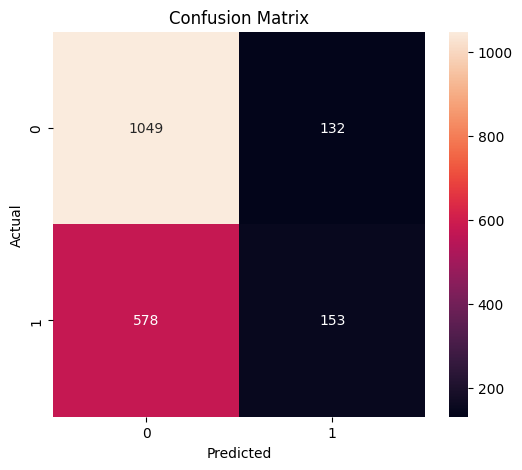

In [26]:
# classification Analysis - logsitic model to classify whether a listing is instantly bookable

class_feats = [
    'price',
    'accommodates',
    'bedrooms',
    'review_scores_rating',
    'availability_365'
]


X = df_clean[class_feats].copy()

y = df_clean['instant_bookable'].copy()
y = y.astype(int)
# Drop NaNs
mask = X.notna().all(axis=1) & y.notna()
X = X[mask]
y = y[mask]
original_rows = len(df_clean)
rows_after_drop = len(X)
rows_dropped = original_rows - rows_after_drop

print(f"Original rows: {original_rows}")
print(f"Rows after dropping NaNs: {rows_after_drop}")
print(f"Rows dropped: {rows_dropped} ({rows_dropped/original_rows:.2%} of data)")

# Optional: Show percentage of data retained
print(f"Data retained: {rows_after_drop/original_rows:.2%}")

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=10
)

# Standardize features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Logistic regression
log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train_scaled, y_train)

# Predictions
y_pred = log_model.predict(X_test_scaled)

# Metrics
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d')

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()


# Classification Results
- Accuracy ~ 63.38% 
- The model correctly predicted whether a listing is instantly bookable 63% of the time. 
- The data set is imbalanced with more non-instant bookable listings (1,181) than instant ones (731). 
- A baseline model that only predicts "not instantly bookable" would be right 61.5% of the time. This model is barely better than that. 

Original rows: 11153
Rows after dropping NaNs: 9565
Rows dropped: 1588


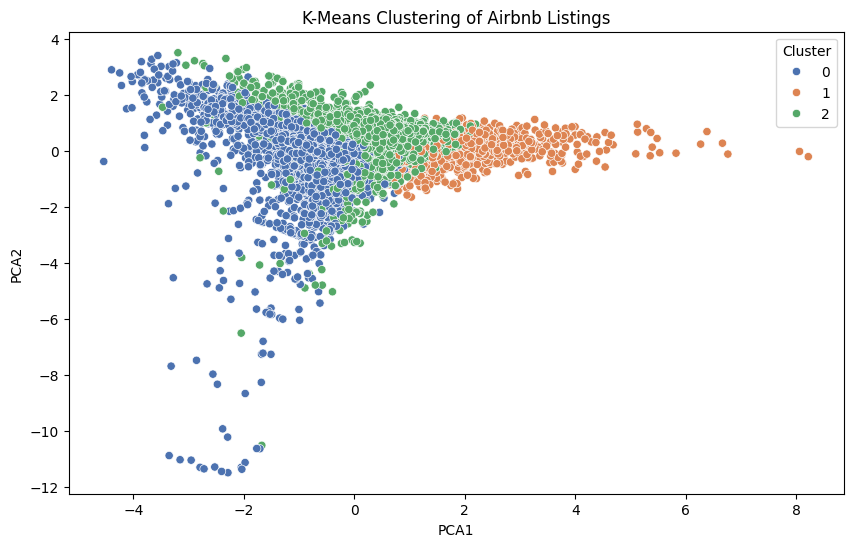


Cluster Distribution:
cluster
0    5409
2    3108
1    1048
Name: count, dtype: int64

          price  review_scores_rating  availability_365  number_of_reviews  \
cluster                                                                      
0        265.56                  4.80            303.77              49.34   
1        153.81                  4.86            229.38             364.64   
2        215.81                  4.84            101.96              57.45   

         count  
cluster         
0         5409  
1         1048  
2         3108  


In [27]:
# Clustering Analysis
# Clustering features
cluster_features = [
    'price',
    'review_scores_rating',
    'availability_365',
    'number_of_reviews'
]

# Select features
X = df_clean[cluster_features].copy()

# Drop rows with any NaN values 
X_clean = X.dropna()

print(f"Original rows: {len(X)}")
print(f"Rows after dropping NaNs: {len(X_clean)}")
print(f"Rows dropped: {len(X) - len(X_clean)}")

# Scale data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(X_clean)

# KMeans Clustering
kmeans = KMeans(n_clusters=3, random_state=10)
clusters = kmeans.fit_predict(scaled_data)

# Add cluster labels back to the cleaned dataframe
X_clean = X_clean.reset_index(drop=True)
X_clean['cluster'] = clusters

# # Optional: Merge clusters back to original df_clean (NaN rows will have no cluster)
# df_clean = df_clean.join(X_clean[['cluster']], how='left')

# PCA for visualization
pca = PCA(n_components=2)
pca_components = pca.fit_transform(scaled_data)

pca_df = pd.DataFrame({
    'PCA1': pca_components[:, 0],
    'PCA2': pca_components[:, 1],
    'Cluster': clusters
})

# Plot clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=pca_df,
    x='PCA1',
    y='PCA2',
    hue='Cluster',
    palette='deep'
)
plt.title('K-Means Clustering of Airbnb Listings')
plt.show()

# Optional: View cluster distribution
print("\nCluster Distribution:")
print(X_clean['cluster'].value_counts())
print('')
# cluster summary stats
cluster_summary = X_clean.groupby('cluster').mean().round(2)
cluster_summary['count'] = X_clean['cluster'].value_counts()
print(cluster_summary)

# Cluster Results
- Cluster 0: premium and more frequently available listings
- Cluster 1: high demand and budget listings
- Cluster 2: mid range listings with limited availability


# advanced analysis - machine learning - random forest - regression & classification

In [28]:
# machine learning via regression analysis

features = [
    'accommodates',
    'bedrooms',
    'review_scores_rating',
    # 'review_scores_cleanliness',
    'availability_365'
]

X = df_clean[features].copy()
y = df_clean['price'].copy()

## handle missing values

original_rows = len(df_clean)

mask = X.notna().all(axis=1) & y.notna()
X = X[mask]
y = y[mask]

print(f'original rows: {original_rows}')
print(f'Rows after dropping nulls: {len(X)}')
print(f'Rows dropped: {original_rows - len(X)} ({(original_rows - len(X))/original_rows:.2%})')
print(f'Data retained: {len(X)/original_rows:.2%}\n')


# train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=10
)

print(f'Training samples: {len(X_train)}')
print(f'Testing samples: {len(X_test)}\n')


# train mutliple models
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(
        n_estimators=300,
        max_depth=12,
        random_state=10,
        n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.1,
        max_depth=8,
        random_state=10
    )
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results.append({
        'Model': name,
        'RMSE': round(rmse, 2),
        'MAE': round(mae, 2),
        'R2': round(r2, 2)
    })

# display results
results_df = pd.DataFrame(results)
print("\n" + "="*50)
print('==== Model Performance Comparison ====')
print("="*50)
print(results_df.sort_values(by='R2', ascending=False).to_string(index=False))


## detailed analysis - linear regression model
print("\n" + "="*50)
print('====Linear Regression Coefficients====')
print("="*50)
lr_model = models['Linear Regression']
coefficients = pd.DataFrame({
    'Feature': features,
    'Coefficient': lr_model.coef_.round(4)
}).sort_values(by='Coefficient', ascending=False)

print(coefficients.to_string(index=False))

## Random forest 

rf_model = models['Random Forest']
importances = pd.DataFrame({
    'Feature': features,
    'Importance': rf_model.feature_importances_.round(4)
}).sort_values(by='Importance', ascending=False)


print(importances.to_string(index=False))





original rows: 11153
Rows after dropping nulls: 9558
Rows dropped: 1595 (14.30%)
Data retained: 85.70%

Training samples: 7646
Testing samples: 1912


==== Model Performance Comparison ====
            Model   RMSE   MAE   R2
Linear Regression 139.24 88.66 0.53
    Random Forest 140.52 86.45 0.52
Gradient Boosting 155.95 95.08 0.41

====Linear Regression Coefficients====
             Feature  Coefficient
            bedrooms      64.4690
review_scores_rating      26.2416
        accommodates      15.8450
    availability_365       0.0189
             Feature  Importance
            bedrooms      0.6228
    availability_365      0.1968
review_scores_rating      0.1062
        accommodates      0.0742


# Evaluate the model performance metrics and interpret the results 
- Linear Regression: best overall balance and accuracy 
- Random Forest: similar perfomance, slightly lower average error
- Gradient Boosting: weakest predictive performance